# Simple Linear Regression

## A straight line from two adjustable numbers

A line predicts temperature by adding a starting value to a change per volt:

$$\text{predicted temperature}=\text{intercept}+\text{slope}\times\text{voltage}.$$

The intercept is the prediction at 0 V. The slope is the increase in predicted temperature for an extra 1 V. Both numbers are coefficients: values chosen during fitting.

Three made-up measurements give a small example that can be calculated directly.

| Voltage (V) | Measured temperature (°C) |
| --- | --- |
| 1 | 20 |
| 2 | 35 |
| 3 | 35 |

First, calculate the two averages:

$$\text{average voltage}=(1+2+3)/3=2,$$
$$\text{average temperature}=(20+35+35)/3=30.$$

Ordinary least squares (OLS) chooses the line with the smallest total squared error. Subtracting the averages gives voltage differences of −1, 0, and 1, and temperature differences of −10, 5, and 5.

Multiply the matching differences and add them for the numerator. Square and add the voltage differences for the denominator:

$$\text{numerator}=(-1)\times(-10)+0\times5+1\times5=15,$$
$$\text{denominator}=(-1)^2+0^2+1^2=2.$$

Dividing gives the slope:

$$\text{slope}=15/2=7.5.$$

The intercept makes the line pass through the pair of averages:

$$\text{intercept}=30-7.5\times2=15.$$

The fitted rule is therefore $\text{temperature}=15+7.5\times\text{voltage}$. If every input voltage were the same, the denominator would be zero: those measurements could not determine a unique slope.

## The distance between a measurement and a prediction

At 2 V, the line predicts $15+7.5\times2=30$ °C, while the measurement is 35 °C. The residual is the signed difference:

$$\text{residual}=\text{measured value}-\text{predicted value}=35-30=5\ ^\circ\mathrm{C}.$$

<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/06-1_Regression/assets/02_residuals_and_squared_error.png" alt="Filled measured dots and open predicted dots with vertical residuals of minus 2.5, plus 5, and minus 2.5 degrees Celsius." width="640" style="max-width:100%;height:auto;">

For all three measurements, the total squared error is:

$$\begin{aligned}
\text{cost}&=(20-22.5)^2+(35-30)^2+(35-37.5)^2\\
&=(-2.5)^2+5^2+(-2.5)^2=37.5\ ^\circ\mathrm{C}^2.
\end{aligned}$$

Squaring makes negative and positive errors add rather than cancel. A large error contributes more than a small one.

## Moving the line across thermometer measurements

The interactive example uses 16 noisy measurements from 0 to 5 V. Blue filled dots are measured temperatures. Teal open dots are predictions at exactly the same voltages. Each gray segment connects one measurement to its prediction.

The intercept moves the line up or down. The slope changes its tilt. The displayed MSE is the average of the squared vertical gaps. `OLS fit` places the line at the minimum of this cost.

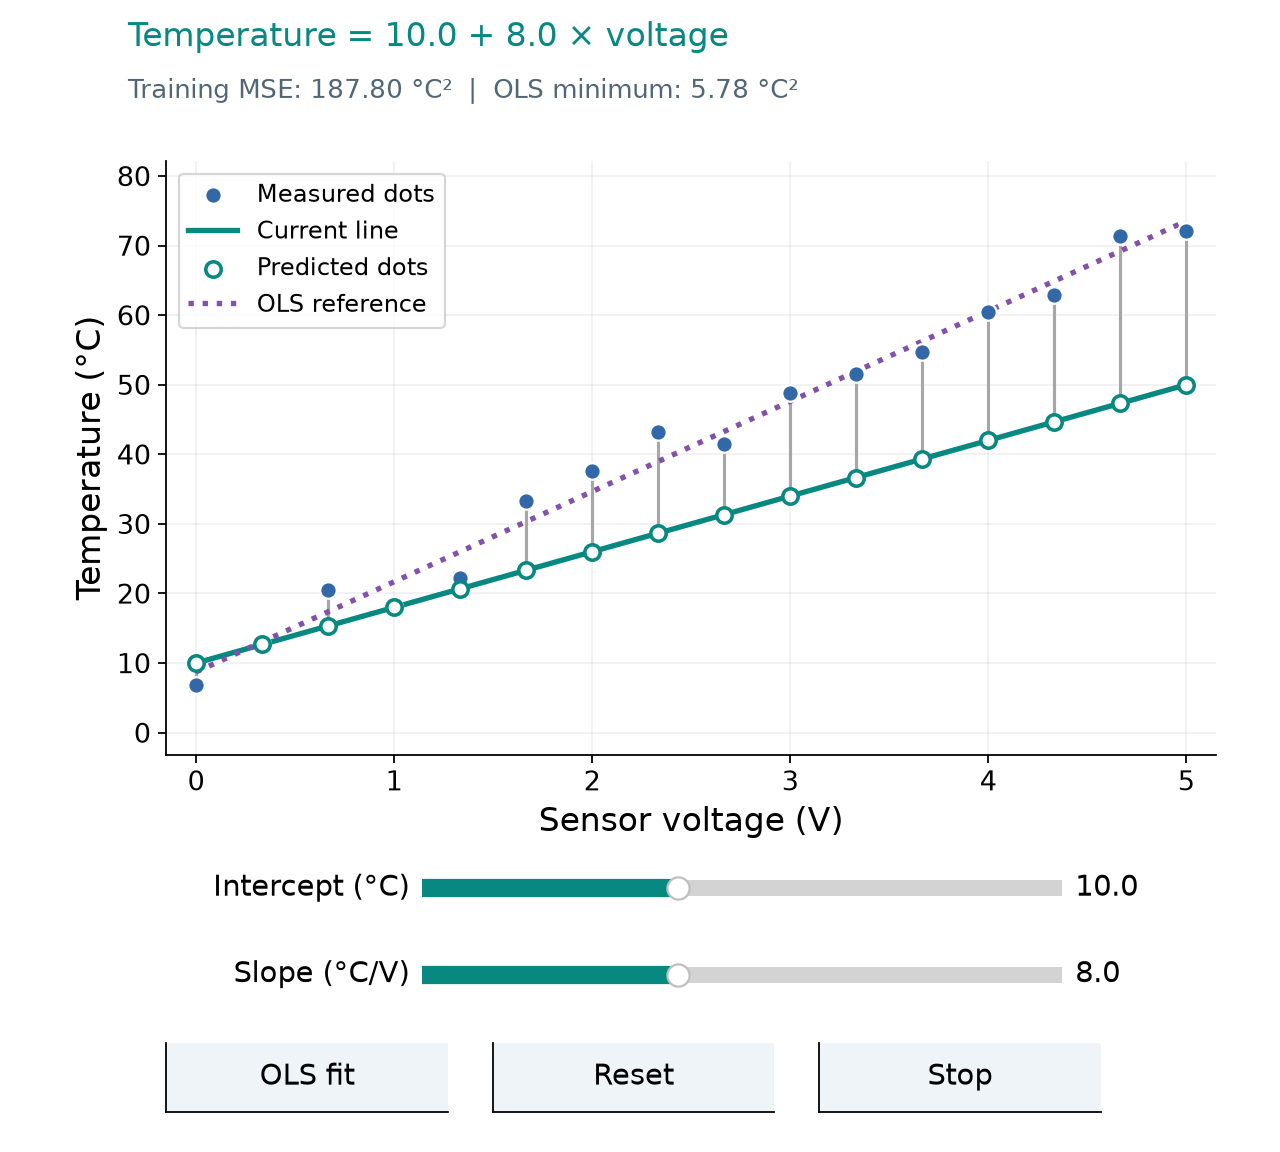

In [1]:
import os
import sys
import io
import base64
from pathlib import Path
from tempfile import gettempdir
import numpy as np
import pandas as pd
import matplotlib

REGRESSION_STATIC = os.environ.get("REGRESSION_STATIC") == "1"
REGRESSION_BROWSER = sys.platform == "emscripten"
if not REGRESSION_STATIC and not REGRESSION_BROWSER:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        shell.run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression

# Bundle the required DejaVu Sans characters for offline browser rendering.
_regression_font = Path(gettempdir()) / "regression-lecture-font.ttf"
_regression_font_data = base64.b64decode("...")
if not _regression_font.exists() or _regression_font.read_bytes() != _regression_font_data:
    _regression_font.write_bytes(_regression_font_data)
font_manager.fontManager.addfont(str(_regression_font))
plt.rcParams.update({
    "font.family": font_manager.FontProperties(fname=str(_regression_font)).get_name(),
    "font.size": 15, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "lines.linewidth": 2.4,
    "axes.unicode_minus": False, "figure.facecolor": "white",
})
BLUE, TEAL, ORANGE, PURPLE = "#3268a8", "#078880", "#d87522", "#8251ac"


def metrics(observed, predicted):
    """R² is undefined for a constant evaluation target."""
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = observed - predicted
    mse = np.mean(error**2)
    total = np.sum((observed - observed.mean())**2)
    return {"MAE": np.mean(np.abs(error)), "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": 1 - np.sum(error**2) / total if total > 0 else np.nan}


# Close earlier views before replacing models or shared callbacks on a rerun.
for _previous_view in globals().get("_regression_views", {}).values():
    _previous_view.close()
_regression_views = {}


class RegressionExplorer:
    """Sliders redraw the model and its metrics from the same observations."""

    def __init__(self, name, render, sliders, actions=(), history=False):
        previous = _regression_views.get(name)
        if previous is not None:
            previous.close()
        self.render = render
        self.running = False
        self.controls, self.buttons, self.state = {}, {}, {}
        self.defaults = {key: initial for key, label, low, high, initial, step, fmt in sliders}
        # 80 dpi gives a 640 px live canvas; saved output uses 160 dpi at the same display size.
        with plt.ioff():
            self.figure = plt.figure(figsize=(8, 8.4 if history else 7.2), dpi=80)
        self.status = self.figure.text(.10, .96, "", fontsize=15, color=TEAL)
        self.detail = self.figure.text(.10, .915, "", fontsize=11.5, color="#536675")
        bottom = .27 + .075 * (len(sliders) - 1)
        if history:
            self.ax = self.figure.add_axes([.13, .56, .82, .30])
            self.history_ax = self.figure.add_axes([.13, .33, .82, .12])
        else:
            self.ax = self.figure.add_axes([.13, bottom, .82, .86 - bottom])
        for i, (key, label, low, high, initial, step, fmt) in enumerate(sliders):
            y = .14 + .075 * (len(sliders) - i - 1)
            slider = Slider(self.figure.add_axes([.33, y, .50, .028]),
                            label, low, high, valinit=initial, valstep=step,
                            valfmt=fmt, color=TEAL)
            slider.label.set_fontsize(13)
            slider.valtext.set_fontsize(13)
            slider.on_changed(self.update)
            self.controls[key] = slider
        commands = list(actions) + [("Reset", lambda view: view.reset()),
                                    ("Stop", lambda view: view.stop())]
        width = min(.22, .8 / len(commands) - .025)
        for i, (label, callback) in enumerate(commands):
            button = Button(self.figure.add_axes([.13 + i*(width+.035), .035, width, .06]),
                            label, color="#eef4f7", hovercolor="#d7e9e6")
            button.label.set_fontsize(13)
            button.on_clicked(lambda event, callback=callback: callback(self))
            self.buttons[label] = button
        self.figure.canvas.mpl_connect("close_event", lambda event: self.stop())
        _regression_views[name] = self
        self.update()

    def update(self, _=None):
        self.ax.clear()
        if hasattr(self, "history_ax"):
            self.history_ax.clear()
        values = {key: slider.val for key, slider in self.controls.items()}
        self.state = self.render(self, **values)
        self.figure.canvas.draw_idle()

    def set_values(self, **values):
        for key, value in values.items():
            slider = self.controls[key]
            events, drawing = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = events, drawing
        self.update()

    def reset(self):
        self.set_values(**self.defaults)

    def start(self):
        if REGRESSION_STATIC:
            buffer = io.BytesIO()
            self.figure.savefig(buffer, format="png", dpi=160, facecolor="white")
            display(Image(data=buffer.getvalue(), width=640,
                          alt=self.status.get_text() + ". " + self.detail.get_text()))
            plt.close(self.figure)
            return
        self.running = True
        if REGRESSION_BROWSER:
            plt.show()
            try:
                while self.running and plt.fignum_exists(self.figure.number):
                    plt.pause(.04)
            finally:
                self.stop()
        elif hasattr(self.figure.canvas, "toolbar_visible"):
            self.figure.canvas.toolbar_visible = False
            self.figure.canvas.header_visible = False
            self.figure.canvas.footer_visible = False
            self.figure.canvas.resizable = False
            display(self.figure.canvas)
        else:
            plt.show()

    def stop(self):
        self.running = False
        for slider in self.controls.values():
            slider.set_active(False)
        for button in self.buttons.values():
            button.set_active(False)
        self.buttons["Stop"].label.set_text("Stopped")
        self.figure.canvas.draw_idle()

    def close(self):
        self.stop()
        plt.close(self.figure)


rng_sensor = np.random.default_rng(60)
voltage_train = np.linspace(0, 5, 16)


def sensor_mean(voltage):
    return 10 + 12 * np.asarray(voltage)


temperature_train = sensor_mean(voltage_train) + rng_sensor.normal(0, 3, 16)
average_voltage = sum(voltage_train) / len(voltage_train)
average_temperature = sum(temperature_train) / len(temperature_train)
# Subtract the averages, multiply the differences, and add the terms.
numerator = sum((v - average_voltage) * (t - average_temperature)
                for v, t in zip(voltage_train, temperature_train))
denominator = sum((v - average_voltage)**2 for v in voltage_train)
slope = numerator / denominator
intercept = average_temperature - slope * average_voltage

sensor_model = LinearRegression().fit(voltage_train[:, None], temperature_train)
np.testing.assert_allclose([intercept, slope],
                           [sensor_model.intercept_, sensor_model.coef_[0]])
fitted_temperature = sensor_model.predict(voltage_train[:, None])


def render_sensor_fit(view, intercept_value, slope_value):
    prediction = intercept_value + slope_value * voltage_train
    result = metrics(temperature_train, prediction)
    optimum = metrics(temperature_train, fitted_temperature)
    ax = view.ax
    ax.vlines(voltage_train, prediction, temperature_train, color="0.65", linewidth=1.4)
    ax.scatter(voltage_train, temperature_train, color=BLUE, s=55, edgecolor="white",
               label="Measured dots", zorder=4)
    ax.plot(voltage_train, prediction, color=TEAL, label="Current line")
    ax.scatter(voltage_train, prediction, facecolors="white", edgecolors=TEAL,
               s=48, linewidths=1.6, zorder=5, label="Predicted dots")
    ax.plot(voltage_train, fitted_temperature, ":", color=PURPLE, label="OLS reference")
    ax.set(xlabel="Sensor voltage (V)", ylabel="Temperature (°C)", xlim=(-.15, 5.15),
           ylim=(min(prediction.min(), temperature_train.min())-10,
                 max(prediction.max(), temperature_train.max())+10))
    ax.legend(loc="upper left")
    view.status.set_text(f"Temperature = {intercept_value:.1f} + {slope_value:.1f} × voltage")
    view.detail.set_text(f"Training MSE: {result['MSE']:.2f} °C²  |  OLS minimum: {optimum['MSE']:.2f} °C²")
    return {"prediction": prediction, "metrics": result, "optimum": optimum}


sensor_fit_demo = RegressionExplorer("sensor_fit", render_sensor_fit, [
    ("intercept_value", "Intercept (°C)", -10, 40, 10, .5, "%0.1f"),
    ("slope_value", "Slope (°C/V)", 0, 20, 8, .1, "%0.1f"),
], actions=[("OLS fit", lambda view: view.set_values(intercept_value=intercept, slope_value=slope))])
sensor_fit_demo.start()

## Joining dots and extending a line

Piecewise linear interpolation joins neighboring measured dots with straight segments. At the halfway point between two voltages, its prediction is halfway between the two measured temperatures. For example:

$$\text{halfway temperature}=20+0.5\times(35-20)=27.5\ ^\circ\mathrm{C}.$$

At one quarter of the gap, the calculation becomes $20+0.25\times(35-20)=23.75$ °C. The fraction describes the new input's position between its two neighbors.

The orange dot moves along the fitted regression line. Beyond 5 V, the shaded region marks extrapolation. Piecewise interpolation returns no value there because there is no measured point on the other side. The regression coefficients remain fixed at the OLS solution.

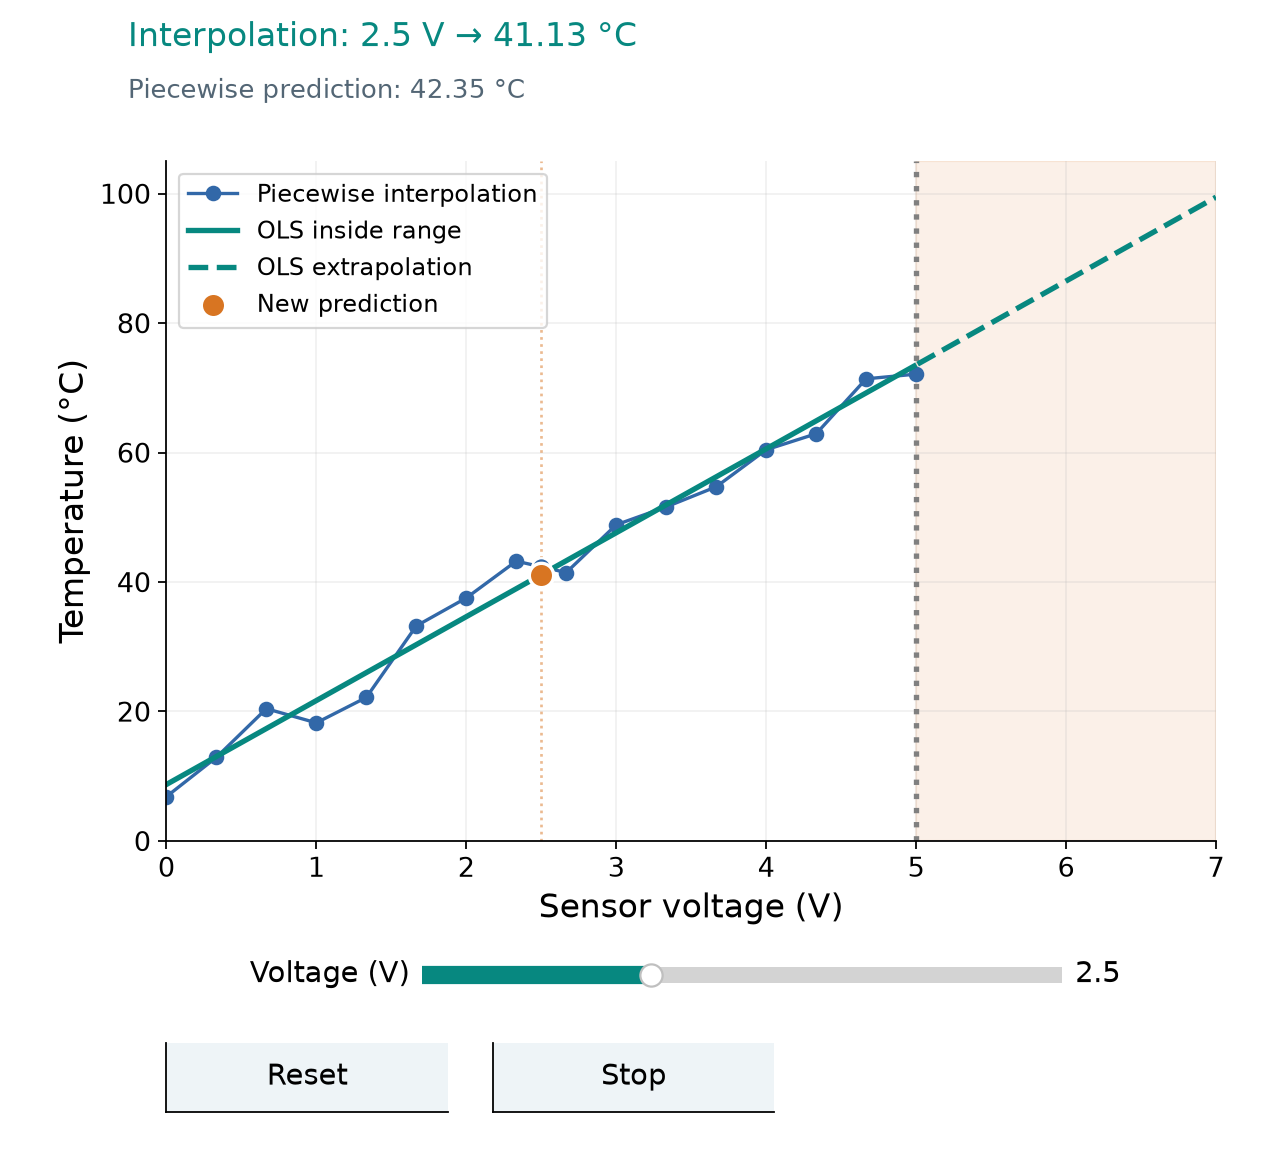

In [2]:
voltage_grid = np.linspace(0, 7, 300)
sensor_line = sensor_model.predict(voltage_grid[:, None])


def render_sensor_query(view, voltage):
    prediction = float(sensor_model.predict([[voltage]])[0])
    piecewise = float(np.interp(voltage, voltage_train, temperature_train,
                                left=np.nan, right=np.nan))
    inside = voltage_grid <= voltage_train.max()
    region = "Interpolation" if voltage_train.min() <= voltage <= voltage_train.max() else "Extrapolation"
    ax = view.ax
    ax.axvspan(5, 7, color=ORANGE, alpha=.10)
    ax.axvline(5, color="0.5", linestyle=":")
    ax.plot(voltage_train, temperature_train, color=BLUE, marker="o", markersize=6,
            linewidth=1.5, label="Piecewise interpolation")
    ax.plot(voltage_grid[inside], sensor_line[inside], color=TEAL, label="OLS inside range")
    ax.plot(voltage_grid[~inside], sensor_line[~inside], "--", color=TEAL, label="OLS extrapolation")
    ax.scatter([voltage], [prediction], s=120, color=ORANGE, edgecolor="white", linewidth=1.5,
               label="New prediction", zorder=6)
    if np.isfinite(piecewise):
        ax.scatter([voltage], [piecewise], s=70, color=BLUE, edgecolor="white", zorder=5)
    ax.set(xlabel="Sensor voltage (V)", ylabel="Temperature (°C)", xlim=(0, 7), ylim=(0, 105))
    ax.axvline(voltage, color=ORANGE, linestyle=":", linewidth=1.2, alpha=.5)
    ax.legend(loc="upper left")
    view.status.set_text(f"{region}: {voltage:.1f} V → {prediction:.2f} °C")
    comparison = f"{piecewise:.2f} °C" if np.isfinite(piecewise) else "undefined outside 0–5 V"
    view.detail.set_text(f"Piecewise prediction: {comparison}")
    return {"voltage": voltage, "prediction": prediction, "piecewise": piecewise, "region": region}


sensor_query_demo = RegressionExplorer("sensor_query", render_sensor_query, [
    ("voltage", "Voltage (V)", 0, 7, 2.5, .1, "%0.1f"),
])
sensor_query_demo.start()

## Turning three errors into an error score

The three-point example had errors of −2.5, 5, and −2.5 °C. The same errors produce several useful scores.

MAE averages the sizes of the errors:

$$\mathrm{MAE}=\frac{2.5+5+2.5}{3}\approx3.33\ ^\circ\mathrm{C}.$$

MSE squares each error before averaging. RMSE takes the square root to return to temperature units:

$$\mathrm{MSE}=\frac{(-2.5)^2+5^2+(-2.5)^2}{3}=12.5\ ^\circ\mathrm{C}^2,$$
$$\mathrm{RMSE}=\sqrt{12.5}\approx3.54\ ^\circ\mathrm{C}.$$

R² compares the total squared error with predicting the observed average, 30 °C, for every point:

$$R^2=1-\frac{37.5}{(20-30)^2+(35-30)^2+(35-30)^2}
=1-\frac{37.5}{150}=0.75.$$

An R² of 1 means perfect predictions; 0 means the same squared error as the average-value reference. R² can be negative when predictions are worse than that reference. It is not an accuracy percentage. If every observed target is identical, the denominator is zero and R² is undefined.

The noise control spreads the thermometer dots farther from the underlying straight trend. The input locations and random noise pattern stay the same. Each model is fitted again using training points only; its error is measured on separate test points. The training-mean baseline uses the training average, while R² uses the average of the points being evaluated.

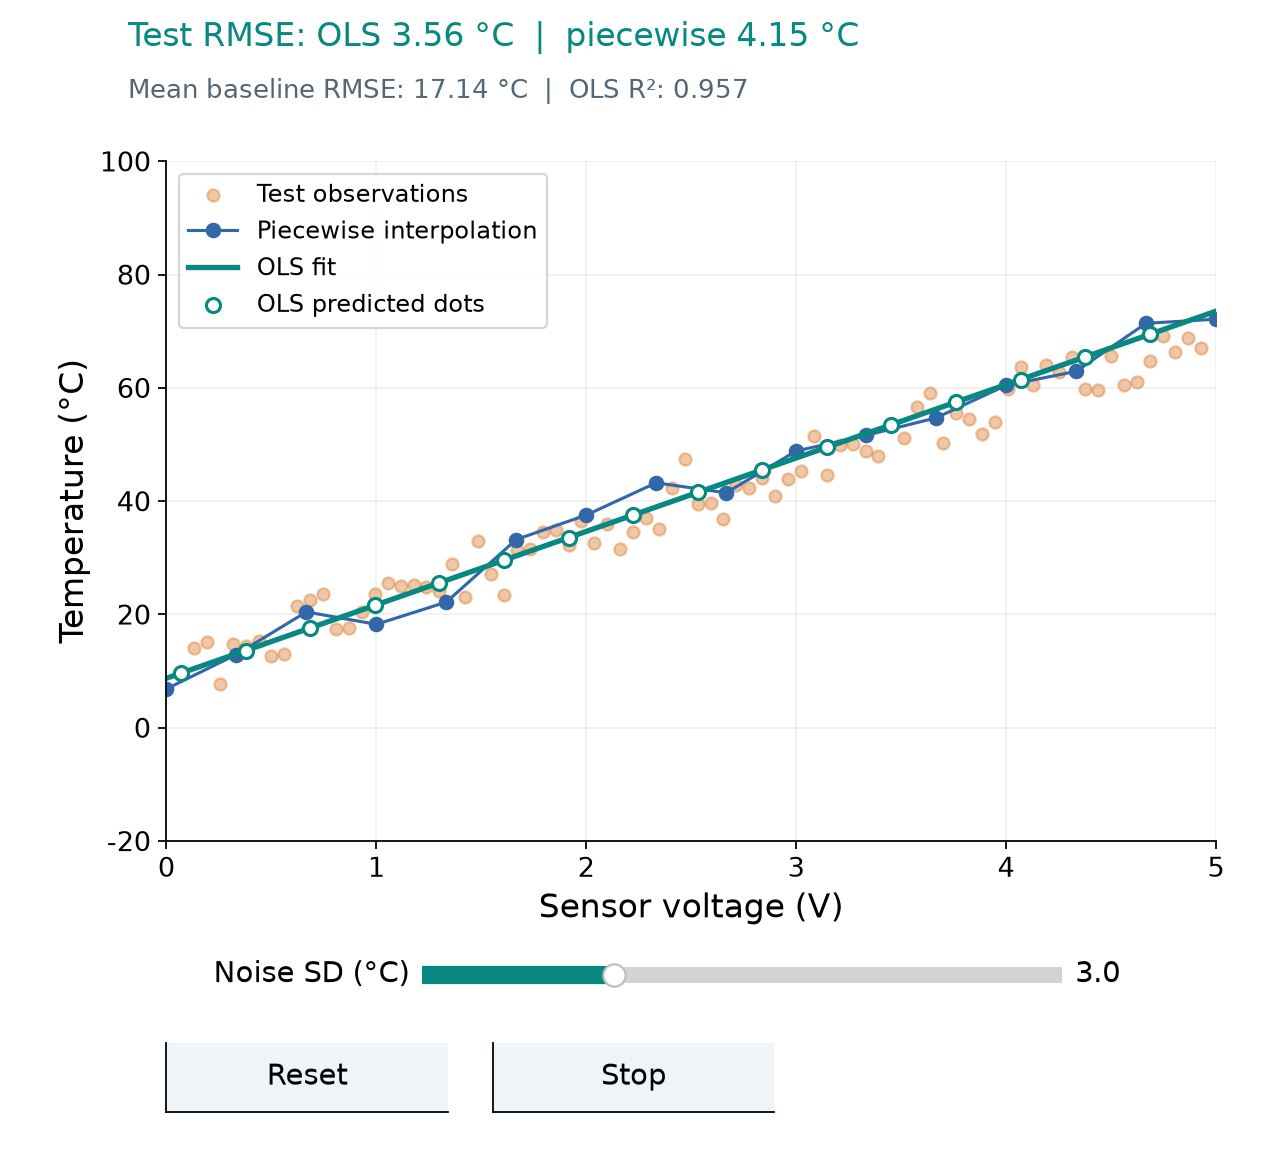

In [3]:
# Fixed standardized noise makes changing its amplitude a controlled comparison.
sensor_noise_rng = np.random.default_rng(60)
sensor_train_noise = sensor_noise_rng.standard_normal(16)
sensor_test_noise = sensor_noise_rng.standard_normal(80)
voltage_test = np.linspace(.07, 4.93, 80)


def render_sensor_noise(view, noise):
    observed_train = sensor_mean(voltage_train) + noise * sensor_train_noise
    observed_test = sensor_mean(voltage_test) + noise * sensor_test_noise
    model = LinearRegression().fit(voltage_train[:, None], observed_train)
    prediction = model.predict(voltage_test[:, None])
    piecewise = np.interp(voltage_test, voltage_train, observed_train)
    baseline = np.full(len(voltage_test), observed_train.mean())
    results = {"Training mean": metrics(observed_test, baseline),
               "Piecewise interpolation": metrics(observed_test, piecewise),
               "OLS regression": metrics(observed_test, prediction)}
    ax = view.ax
    ax.scatter(voltage_test, observed_test, color=ORANGE, alpha=.4, s=30, label="Test observations")
    ax.plot(voltage_train, observed_train, "o-", color=BLUE, markersize=6,
            linewidth=1.4, label="Piecewise interpolation")
    ax.plot(voltage_train, model.predict(voltage_train[:, None]), color=TEAL, label="OLS fit")
    ax.scatter(voltage_test[::5], prediction[::5], facecolors="white", edgecolors=TEAL,
               s=40, linewidths=1.4, zorder=5, label="OLS predicted dots")
    ax.set(xlabel="Sensor voltage (V)", ylabel="Temperature (°C)", xlim=(0, 5), ylim=(-20, 100))
    ax.legend(loc="upper left")
    view.status.set_text(f"Test RMSE: OLS {results['OLS regression']['RMSE']:.2f} °C  |  piecewise {results['Piecewise interpolation']['RMSE']:.2f} °C")
    view.detail.set_text(f"Mean baseline RMSE: {results['Training mean']['RMSE']:.2f} °C  |  OLS R²: {results['OLS regression']['R²']:.3f}")
    return {"train": observed_train, "test": observed_test, "prediction": prediction,
            "piecewise": piecewise, "metrics": results, "model": model}


sensor_noise_demo = RegressionExplorer("sensor_noise", render_sensor_noise, [
    ("noise", "Noise SD (°C)", 0, 10, 3, .5, "%0.1f"),
])
sensor_noise_demo.start()

Joining every training dot gives zero training error, including the noise in those dots. It need not give the smallest error on new measurements. In this simulation, a straight line can recover the underlying trend by combining information from many noisy points.